In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def pipline_global(image):
    his=cv2.equalizeHist(image)
    gamma=1.2
    inv_gamma=1.0/gamma
    table=np.array([((i/255.0)**inv_gamma)*255 for i in np.arange(0,256)]).astype("uint8")
    return cv2.LUT(his, table)

In [3]:
def pipline_adaptive(image):
    clahe=cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cimg=clahe.apply(image)
    gauss=cv2.GaussianBlur(cimg, (0,0), 2.0)
    unsharp=cv2.addWeighted(cimg, 1.5, gauss, -0.5, 0)
    return unsharp

In [4]:
def pipeline_frequency_natural(img_gray):
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    rows, cols = img_gray.shape
    crow, ccol = rows // 2, cols // 2
    ghpf = np.ones((rows, cols), np.float32)
    sigma=30
    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i - crow) ** 2 + (j - ccol) ** 2)
            ghpf[i, j] = 1 - np.exp(-(d ** 2) / (2 * (sigma ** 2)))
    fshift_filtered = fshift * ghpf
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    k=1.5
    sharpen=img_gray+k*img_back
    sharpen=np.clip(sharpen, 0, 255)
    return sharpen

In [5]:
def pipeline_enhance_xray(img_gray):
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    rows, cols = img_gray.shape
    crow, ccol = rows // 2, cols // 2
    sigma = 30
    offset = 0.5 
    gain = 1.5    
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    d_squared = x*x + y*y
    ghpf = 1 - np.exp(-(d_squared) / (2 * (sigma**2)))
    hfe_mask = offset + gain * ghpf
    fshift_filtered = fshift * hfe_mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.real(np.fft.ifft2(f_ishift))
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_img = clahe.apply(img_back)
    return enhanced_img

In [ ]:
def compare_results(original, p1, p2, p3, p4):
    titles = ['Original', 'HE+Gamma', 'CLAHE+UM', 'Frequency domain','Frequency domain + CLAHE']
    images = [original, p1, p2, p3, p4]
    plt.figure(figsize=(16, 10))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

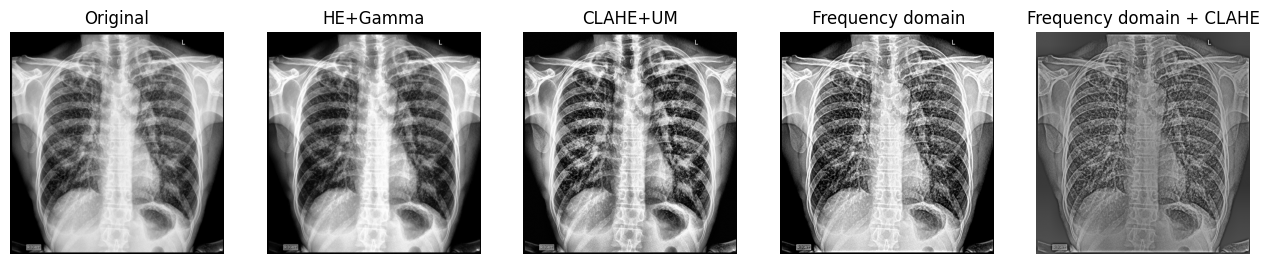

In [7]:
first=cv2.imread(r"D:\computer vision\xray.jpeg",0)
compare_results(first, pipline_global(first), pipline_adaptive(first), pipeline_frequency_natural(first), pipeline_enhance_xray(first))